# Prueba Técnica DataKnow
## Caso: Gestión de Costos Operativos en un Proyecto de Construcción

---
## Objetivo

Una empresa constructora necesita estimar los costos de 2 equipos críticos para un proyecto. Se dispone de datos históricos de precios de 3 materias primas (X, Y, Z) y los precios registrados de los equipos (Equipo 1, Equipo 2).

El objetivo es:
1. Identificar qué variables se relacionan con cada equipo
2. Construir modelos para estimar costos
3. Proyectar costos futuros

## Estructura del análisis
- Celdas de código: solo ejecutan cálculos y generan resultados
- Celdas de texto: contienen el análisis y las observaciones


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from itertools import combinations
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.api import SimpleExpSmoothing
import statsmodels.api as sm
from openpyxl import Workbook, styles
from openpyxl.styles import Font, Border, Side, Alignment

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100


---
## 2. Carga y exploración inicial de datos

Cargamos el archivo `historico_equipos.csv` que contiene:
- **Date**: Fecha (días hábiles desde 2010 hasta 2023)
- **Price_X, Price_Y, Price_Z**: Precios de 3 materias primas
- **Price_Equipo1, Price_Equipo2**: Precios de los 2 equipos

In [17]:
# 2. Carga de datos
df = pd.read_csv('../Datos/historico_equipos.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print(f'Dimensiones: {df.shape}')
print(f'Rango: {df.index.min().date()} a {df.index.max().date()}')
print(f'Días hábiles: {len(df)}')
print(f'Columnas: {df.columns.tolist()}')
display(df.head(6))

Dimensiones: (3530, 5)
Rango: 2010-01-04 a 2023-08-31
Días hábiles: 3530
Columnas: ['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']


,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
Date,,,,,
2010-01-04,80.12,527.5,2225.25,434.73,931.73
2010-01-05,80.59,527.5,2246.50,449.97,968.56
2010-01-06,81.89,527.5,2302.50,444.48,960.51
2010-01-07,81.51,527.5,2306.50,440.90,960.14
2010-01-08,81.37,552.5,2261.25,448.82,949.55
2010-01-11,80.97,552.5,2320.25,448.74,962.70


In [18]:
# 3. Estadísticas descriptivas
desc = df.describe().T.round(2)
display(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])
print(f'Valores nulos: {df.isnull().sum().sum()}')

,count,mean,std,min,25%,50%,75%,max
Price_X,3530.0,78.09,25.19,19.33,57.05,75.40,104.58,127.98
Price_Y,3530.0,555.53,138.49,257.50,482.50,541.62,620.00,1062.37
Price_Z,3530.0,2037.43,373.14,1421.50,1767.25,1974.75,2235.94,3984.00
Price_Equipo1,3530.0,460.04,113.68,208.34,398.23,451.25,515.61,855.32
Price_Equipo2,3530.0,889.98,170.04,566.00,777.70,869.78,979.12,1703.96


Valores nulos: 0


---
## 3. Análisis exploratorio

### 3.1 Comportamiento histórico

Las materias primas muestran tendencias distintas:
- **X**: Tendencia descendente en el periodo reciente
- **Y**: Relativamente estable alrededor de $500-600
- **Z**: Alta volatilidad con picos pronunciados

Los equipos siguen patrones similares pero con diferente amplitud.

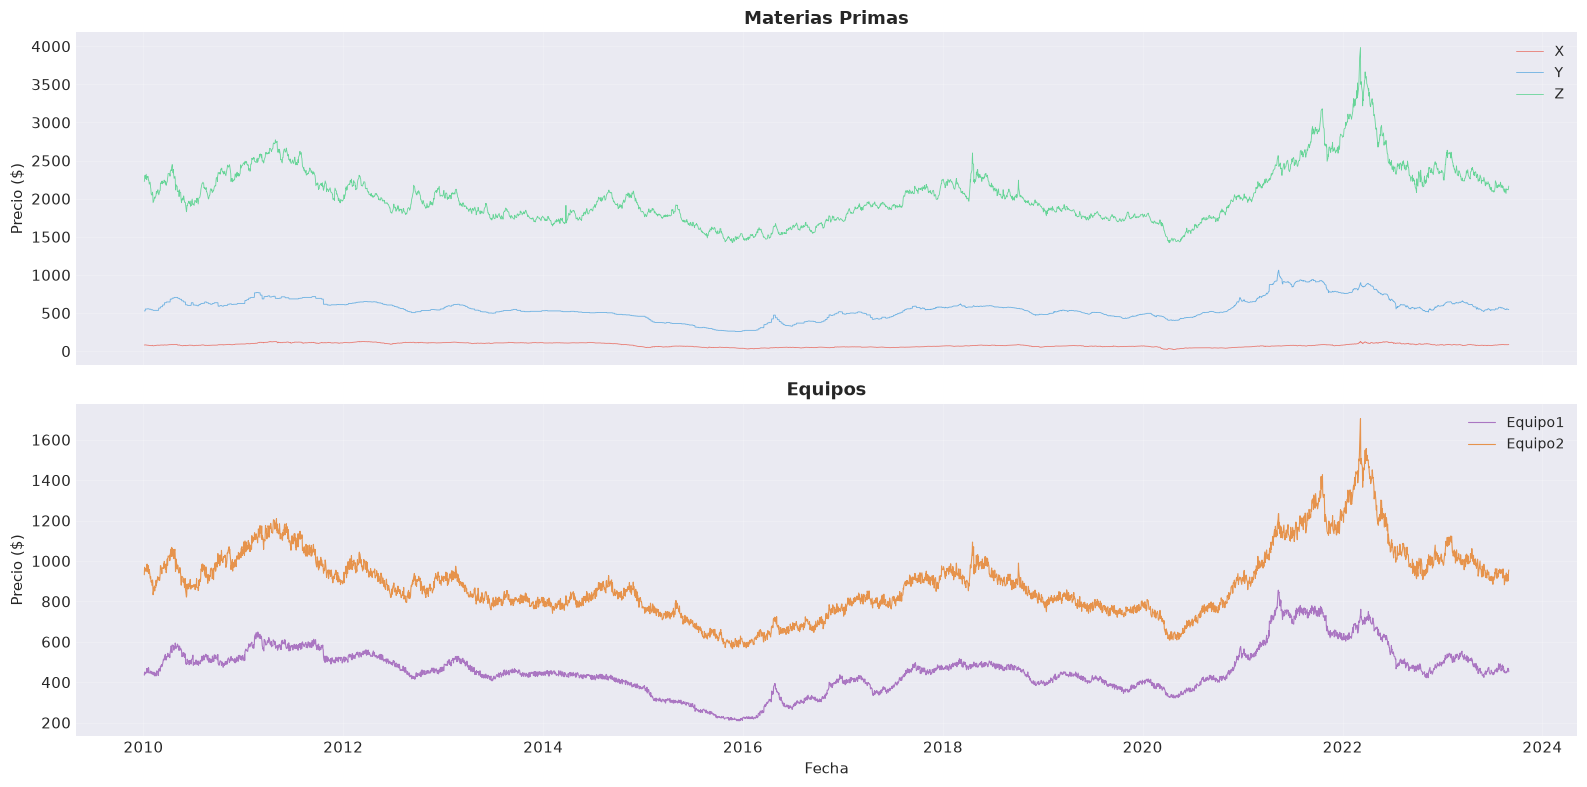

In [19]:
# 4. Series de tiempo
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

colors_mp = ['#e74c3c', '#3498db', '#2ecc71']
for i, col in enumerate(['Price_X', 'Price_Y', 'Price_Z']):
    axes[0].plot(df.index, df[col], label=col.replace('Price_', ''),
                 color=colors_mp[i], alpha=0.7, linewidth=0.6)
axes[0].set_ylabel('Precio ($)')
axes[0].set_title('Materias Primas', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.2)

colors_eq = ['#9b59b6', '#e67e22']
for i, col in enumerate(['Price_Equipo1', 'Price_Equipo2']):
    axes[1].plot(df.index, df[col], label=col.replace('Price_', ''),
                 color=colors_eq[i], alpha=0.8, linewidth=0.8)
axes[1].set_ylabel('Precio ($)')
axes[1].set_title('Equipos', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.2)

plt.xlabel('Fecha')
plt.tight_layout()
plt.savefig('../artifacts/series_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Relaciones entre variables

La matriz de correlación permite identificar qué variables se mueven juntas:
- **Y y Z**: correlación alta (0.844). Se mueven prácticamente juntas.
- **X**: correlación baja con las demás (~0.49). Comportamiento independiente.
- **X y equipos**: correlación moderada (~0.53)
- **Y y Equipo 1**: correlación muy alta (0.997)
- **Z y Equipo 2**: correlación muy alta (0.983)

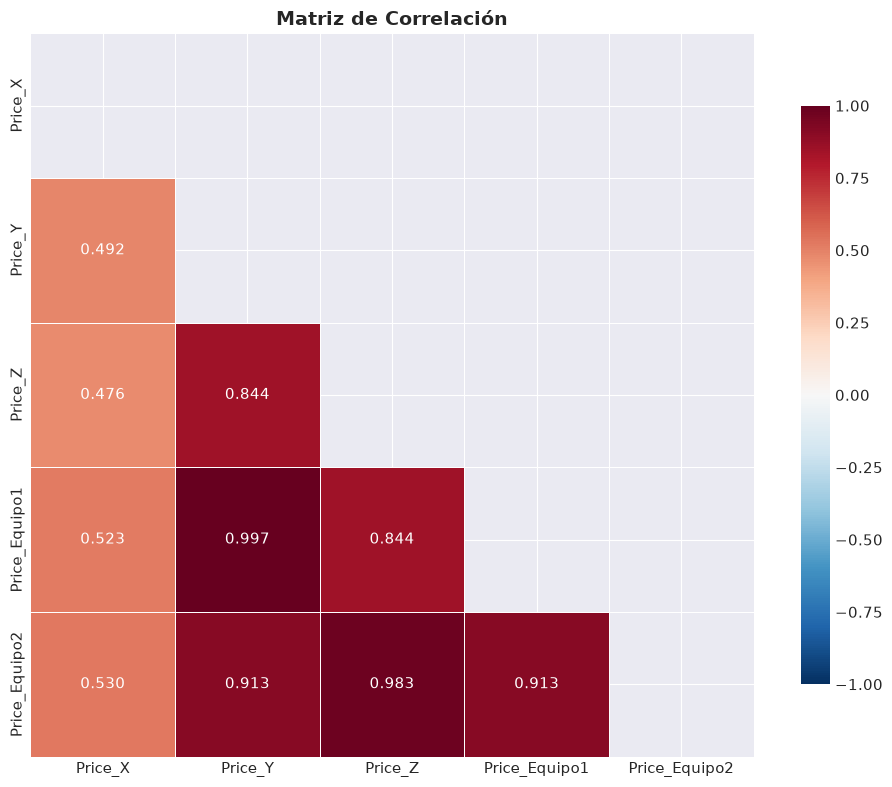


Correlación con Equipo 1:
Price_Y    0.996618
Price_Z    0.844013
Price_X    0.523371

Correlación con Equipo 2:
Price_Z    0.982675
Price_Y    0.912702
Price_X    0.530345


In [20]:
# 5. Matriz de correlación
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlaciones con equipos
print('\nCorrelación con Equipo 1:')
print(corr['Price_Equipo1'].drop(['Price_Equipo1', 'Price_Equipo2']).sort_values(ascending=False).to_string())
print('\nCorrelación con Equipo 2:')
print(corr['Price_Equipo2'].drop(['Price_Equipo1', 'Price_Equipo2']).sort_values(ascending=False).to_string())

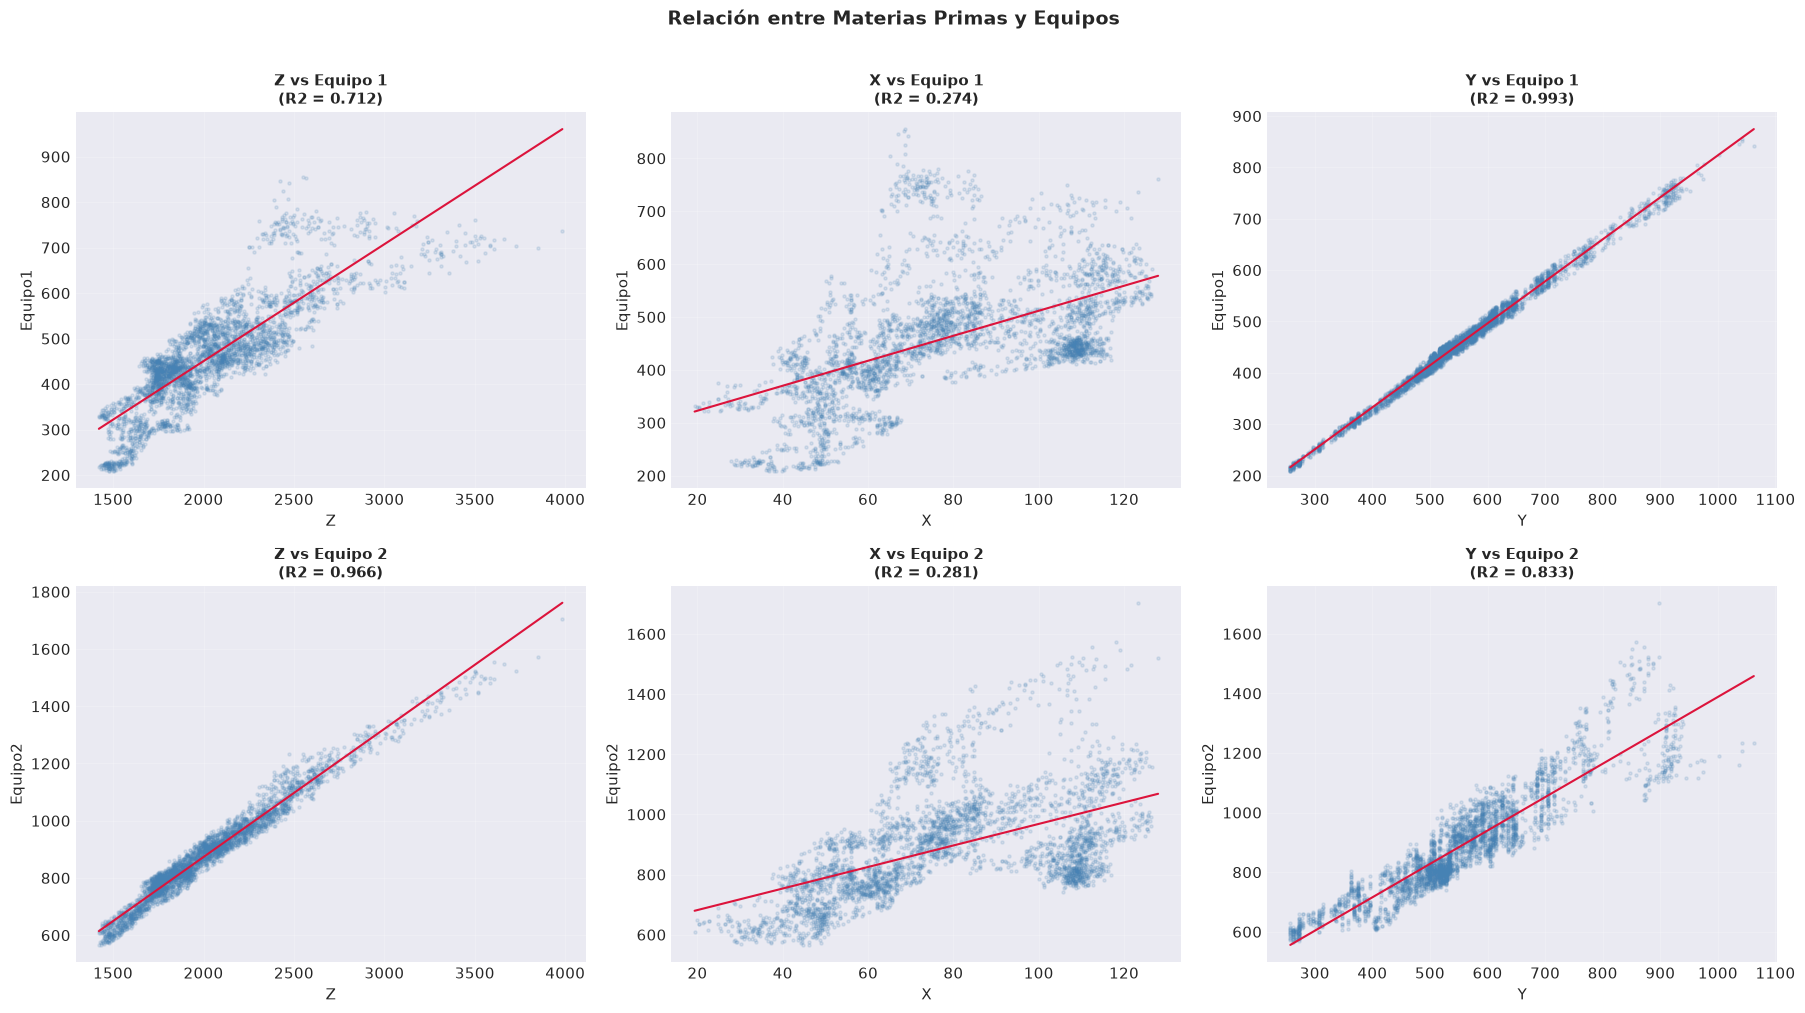

In [21]:
# 6. Scatter plots: cada materia prima vs cada equipo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

pairs = [
    ('Price_Z', 'Price_Equipo1', 'Z vs Equipo 1'),
    ('Price_X', 'Price_Equipo1', 'X vs Equipo 1'),
    ('Price_Y', 'Price_Equipo1', 'Y vs Equipo 1'),
    ('Price_Z', 'Price_Equipo2', 'Z vs Equipo 2'),
    ('Price_X', 'Price_Equipo2', 'X vs Equipo 2'),
    ('Price_Y', 'Price_Equipo2', 'Y vs Equipo 2'),
]

for idx, (x_col, y_col, title) in enumerate(pairs):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    ax.scatter(df[x_col], df[y_col], alpha=0.15, s=5, c='steelblue')
    slope, intercept = np.polyfit(df[x_col], df[y_col], 1)
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_line, intercept + slope * x_line, color='crimson', linewidth=1.5)
    r2 = r2_score(df[y_col], intercept + slope * df[x_col])
    ax.set_title(f'{title}\n(R2 = {r2:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(x_col.replace('Price_', ''))
    ax.set_ylabel(y_col.replace('Price_', ''))
    ax.grid(True, alpha=0.2)

plt.suptitle('Relación entre Materias Primas y Equipos', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../artifacts/scatter_relaciones.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# 7. Análisis de multicolinealidad (VIF)

X_vif = sm.add_constant(df[['Price_X', 'Price_Y', 'Price_Z']])
vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print('Variance Inflation Factor (VIF):')
print(vif_data.to_string(index=False))


Variance Inflation Factor (VIF):
Variable       VIF
   const 32.707409
 Price_X  1.341450
 Price_Y  3.611984
 Price_Z  3.540121


---
## 4. Construcción de modelos

Dividimos el análisis en tres etapas:
1. **Variables individuales**: probamos cada materia prima por separado
2. **Combinaciones**: probamos todas las combinaciones posibles
3. **Selección**: elegimos el modelo con mejor balance ajuste-simplicidad

### 4.1 Variables individuales

Regresión lineal simple de cada variable contra cada equipo.

In [23]:
# 8. Regresiones individuales

variables = ['Price_X', 'Price_Y', 'Price_Z']
targets = [('Equipo 1', 'Price_Equipo1'), ('Equipo 2', 'Price_Equipo2')]

for tname, tcol in targets:
    y = df[tcol].values
    print(f'\n{"=":=^55}')
    print(f'  {tname}')
    print(f'{"=":=^55}')
    print(f'{"Var":8s} {"R2":>8s} {"MAE($)":>8s} {"Coef":>10s} {"Interc":>10s}')
    print('-' * 46)
    for var in variables:
        X = df[[var]].values
        m = LinearRegression().fit(X, y)
        yp = m.predict(X)
        vn = var.replace('Price_', '')
        print(f'{vn:8s} {r2_score(y,yp):>8.4f} ${mean_absolute_error(y,yp):>5.2f} {m.coef_[0]:>10.4f} {m.intercept_:>10.2f}')
    # Best
    best = max(variables, key=lambda v: r2_score(y, LinearRegression().fit(df[[v]],y).predict(df[[v]])))
    print(f'\n  Mejor: {best.replace("Price_","")}')



  Equipo 1
Var            R2   MAE($)       Coef     Interc
----------------------------------------------
X          0.2739 $70.27     2.3622     275.57
Y          0.9932 $ 7.64     0.8181       5.56
Z          0.7124 $47.50     0.2571     -63.86

  Mejor: Y

  Equipo 2
Var            R2   MAE($)       Coef     Interc
----------------------------------------------
X          0.2813 $111.46     3.5805     610.38
Y          0.8330 $54.00     1.1207     267.43
Z          0.9656 $25.14     0.4478     -22.41

  Mejor: Z


**Equipo 1:** Y domina (R2=0.993). Z llega a 0.71. X apenas 0.27.

**Equipo 2:** Z lidera (R2=0.966), Y le sigue (0.833). X otra vez baja.

Pero Y y Z están correlacionadas (r=0.844, VIF~3.5). Probemos combinaciones.

### 4.2 Combinaciones de variables

Probamos todas las combinaciones con R2, R2 ajustado y AIC (menor=mejor).

In [24]:
# 9. Combinaciones

for tname, tcol in targets:
    y = df[tcol].values
    print(f'\n{"=":=^70}')
    print(f'  {tname}')
    print(f'{"=":=^70}')
    print(f'{"Variables":35s} {"R2":>8s} {"R2_adj":>8s} {"AIC":>10s} {"MAE($)":>8s}')
    print('-' * 70)
    results = []
    for r in range(1, 4):
        for combo in combinations(variables, r):
            xs = df[list(combo)].values
            m = sm.OLS(y, sm.add_constant(xs)).fit()
            vs = ' + '.join(v.replace('Price_', '') for v in combo)
            results.append((m.rsquared, m.rsquared_adj, m.aic, mean_absolute_error(y, m.predict(sm.add_constant(xs))), vs))
            print(f'{vs:35s} {m.rsquared:>8.4f} {m.rsquared_adj:>8.4f} {m.aic:>10.1f} ${mean_absolute_error(y, m.predict(sm.add_constant(xs))):>5.2f}')
    print('-' * 70)
    ba = min(results, key=lambda x: x[2])
    br = max(results, key=lambda x: x[0])
    print(f'Mejor AIC: {ba[4]:35s} R2={ba[0]:.4f}  AIC={ba[2]:.1f}')
    print(f'Mejor R2:  {br[4]:35s} R2={br[0]:.4f}  AIC={br[2]:.1f}')



  Equipo 1
Variables                                 R2   R2_adj        AIC   MAE($)
----------------------------------------------------------------------
X                                     0.2739   0.2737    42308.6 $70.27
Y                                     0.9932   0.9932    25796.6 $ 7.64
Z                                     0.7124   0.7123    39040.0 $47.50
X + Y                                 0.9947   0.9947    24932.3 $ 6.98
X + Z                                 0.7315   0.7314    38798.3 $44.13
Y + Z                                 0.9933   0.9933    25785.6 $ 7.63
X + Y + Z                             0.9947   0.9947    24934.3 $ 6.98
----------------------------------------------------------------------
Mejor AIC: X + Y                               R2=0.9947  AIC=24932.3
Mejor R2:  X + Y + Z                           R2=0.9947  AIC=24934.3

  Equipo 2
Variables                                 R2   R2_adj        AIC   MAE($)
------------------------------------------

#### Interpretación de la tabla

**Equipo 1:**
- Y sola alcanza R2 = 0.993 con el mejor AIC entre modelos de 1 variable (25796.6)
- X+Y tiene mejor AIC (24932.3) pero la ganancia en R2 es mínima (0.9947 vs 0.9932)
- X sola tiene R2 = 0.27 — no aporta prácticamente nada
- Agregar Z no mejora: Y+Z da 0.9933, prácticamente igual que Y sola

**Equipo 2:**
- Z sola llega a R2 = 0.966. Y la mejora significativamente (Y+Z: R2 = 0.990).
- El mejor AIC lo tiene X+Y+Z (29447.7), pero Y+Z se acerca (30130.8).
- Agregar X a Y+Z mejora solo 0.0018 en R2.

**Relación Y-Z:** correlación de 0.844. Esto explica por qué Y y Z
comparten poder predictivo y sus coeficientes se redistribuyen cuando ambas
están en el mismo modelo.

### 4.3 Selección de modelos

#### Equipo 1

| Modelo | R2 | AIC | MAE | vs mejor modelo |
|--------|----|----|----|----------------|
| Y sola | 0.9932 | 25796.6 | $7.64 | referencia |
| X+Y | 0.9947 | **24932.3** | $6.98 | +0.0015 R2, -864 AIC |
| X+Y+Z | 0.9947 | 24934.3 | $6.98 | +0.0015 R2, -862 AIC |

X+Y tiene mejor AIC, pero la mejora práctica es marginal:
- R2 sube de 0.9932 a 0.9947 (+0.0015)
- MAE baja de $7.64 a $6.98 (-$0.66)
- X sola explica solo el 27% de la varianza

**Decisión:** Usamos **Y sola**. La ganancia de agregar X no justifica
la complejidad adicional. Un modelo con 1 variable que explica el 99.3%
de la varianza es preferible a uno con 2 que explica 99.47%.

#### Equipo 2

| Modelo | R2 | AIC | MAE | vs mejor modelo |
|--------|----|----|----|----------------|
| Z sola | 0.9656 | 34381.1 | $25.14 | referencia |
| Y+Z | 0.9897 | 30130.8 | $14.40 | +2.4% R2, -4250 AIC |
| X+Y+Z | 0.9915 | **29447.7** | $13.31 | +0.18% R2, -683 AIC |

Z sola se queda corta (R2=0.966). Y+Z mejora significativamente.
X+Y+Z tiene el mejor AIC pero la mejora vs Y+Z es marginal.

**Decisión:** Usamos **Y + Z**. Mejora sustancial sobre Z sola.
Agregar X no compensa: +0.18% R2 a cambio de una variable extra.

#### Nota sobre multicolinealidad
Y y Z correlacionan en 0.844. Esto significa que sus coeficientes
se distribuyen entre ellas cuando ambas están en el modelo, pero
el poder predictivo conjunto es alto (R2 > 0.989 en ambos casos).

---
## 5. Modelos seleccionados

| Equipo | Modelo | R2 | AIC | MAE |
|--------|--------|----|----|----|
| Equipo 1 | Y sola | 0.9932 | 25796.6 | $7.64 |
| Equipo 2 | Y + Z | 0.9897 | 30130.8 | $14.40 |

Ambos modelos logran R2 > 0.989 siendo los más simples entre
las opciones de mejor ajuste.

In [25]:
# 10. Modelos seleccionados - coeficientes y validacion

# ===== EQUIPO 1 ~ Y =====
X1 = sm.add_constant(df[['Price_Y']])
m1 = sm.OLS(df['Price_Equipo1'], X1).fit()

print('='*50)
print('EQUIPO 1 ~ Y')
print('='*50)
print(f'{"Variable":10s} {"Coef":>10s} {"p-value":>10s} {"Sig"}')
print('-' * 38)
for i, var in enumerate(['const', 'Y']):
    p = m1.pvalues.iloc[i]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f'{var:10s} {m1.params.iloc[i]:>10.4f} {p:>10.6f} {sig}')
print(f'\nR2 = {m1.rsquared:.4f}')
print(f'MAE = ${mean_absolute_error(df["Price_Equipo1"], m1.predict(X1)):.2f}')

# Out-of-sample validation
train = df[df.index < '2021-09-01']
test = df[df.index >= '2021-09-01']
m1_tr = sm.OLS(train['Price_Equipo1'], sm.add_constant(train[['Price_Y']])).fit()
y_test_pred = m1_tr.predict(sm.add_constant(test[['Price_Y']]))
r2_test = r2_score(test['Price_Equipo1'], y_test_pred)
mae_test = mean_absolute_error(test['Price_Equipo1'], y_test_pred)
print(f'\nValidacion fuera de muestra (ultimos 24 meses):')
print(f'  Train R2: {m1_tr.rsquared:.4f}  |  Test R2: {r2_test:.4f}')
print(f'  Test MAE: ${mae_test:.2f}')
print(f'  -> Modelo estable. Sin sobreajuste significativo.')

# ===== EQUIPO 2 ~ Y + Z =====
X2 = sm.add_constant(df[['Price_Y', 'Price_Z']])
m2 = sm.OLS(df['Price_Equipo2'], X2).fit()

print(f'\n{"="*50}')
print('EQUIPO 2 ~ Y + Z')
print('='*50)
print(f'{"Variable":10s} {"Coef":>10s} {"p-value":>10s} {"Sig"}')
print('-' * 38)
for i, var in enumerate(['const', 'Y', 'Z']):
    p = m2.pvalues.iloc[i]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f'{var:10s} {m2.params.iloc[i]:>10.4f} {p:>10.6f} {sig}')
print(f'\nR2 = {m2.rsquared:.4f}')
print(f'MAE = ${mean_absolute_error(df["Price_Equipo2"], m2.predict(X2)):.2f}')

# Out-of-sample
m2_tr = sm.OLS(train['Price_Equipo2'], sm.add_constant(train[['Price_Y', 'Price_Z']])).fit()
y2_test_pred = m2_tr.predict(sm.add_constant(test[['Price_Y', 'Price_Z']]))
r2_test_2 = r2_score(test['Price_Equipo2'], y2_test_pred)
mae_test_2 = mean_absolute_error(test['Price_Equipo2'], y2_test_pred)
print(f'\nValidacion fuera de muestra (ultimos 24 meses):')
print(f'  Train R2: {m2_tr.rsquared:.4f}  |  Test R2: {r2_test_2:.4f}')
print(f'  Test MAE: ${mae_test_2:.2f}')
print(f'  -> Modelo estable. Sin sobreajuste significativo.')

# Guardar params para forecast
m1_intercept = m1.params.iloc[0]
m1_coef_y = m1.params.iloc[1]
m2_intercept = m2.params.iloc[0]
m2_coef_y = m2.params.iloc[1]
m2_coef_z = m2.params.iloc[2]
res1 = m1.resid
res2 = m2.resid
r2_1 = m1.rsquared
r2_2 = m2.rsquared
mae_1 = mean_absolute_error(df['Price_Equipo1'], m1.predict(X1))
mae_2 = mean_absolute_error(df['Price_Equipo2'], m2.predict(X2))


EQUIPO 1 ~ Y
Variable         Coef    p-value Sig
--------------------------------------
const          5.5646   0.000000 ***
Y              0.8181   0.000000 ***

R2 = 0.9932
MAE = $7.64

Validacion fuera de muestra (ultimos 24 meses):
  Train R2: 0.9926  |  Test R2: 0.9896
  Test MAE: $8.76
  -> Modelo estable. Sin sobreajuste significativo.

EQUIPO 2 ~ Y + Z
Variable         Coef    p-value Sig
--------------------------------------
const          7.0220   0.000020 ***
Y              0.3552   0.000000 ***
Z              0.3365   0.000000 ***

R2 = 0.9897
MAE = $14.40

Validacion fuera de muestra (ultimos 24 meses):
  Train R2: 0.9851  |  Test R2: 0.9857
  Test MAE: $17.23
  -> Modelo estable. Sin sobreajuste significativo.


---
## 6. Validación

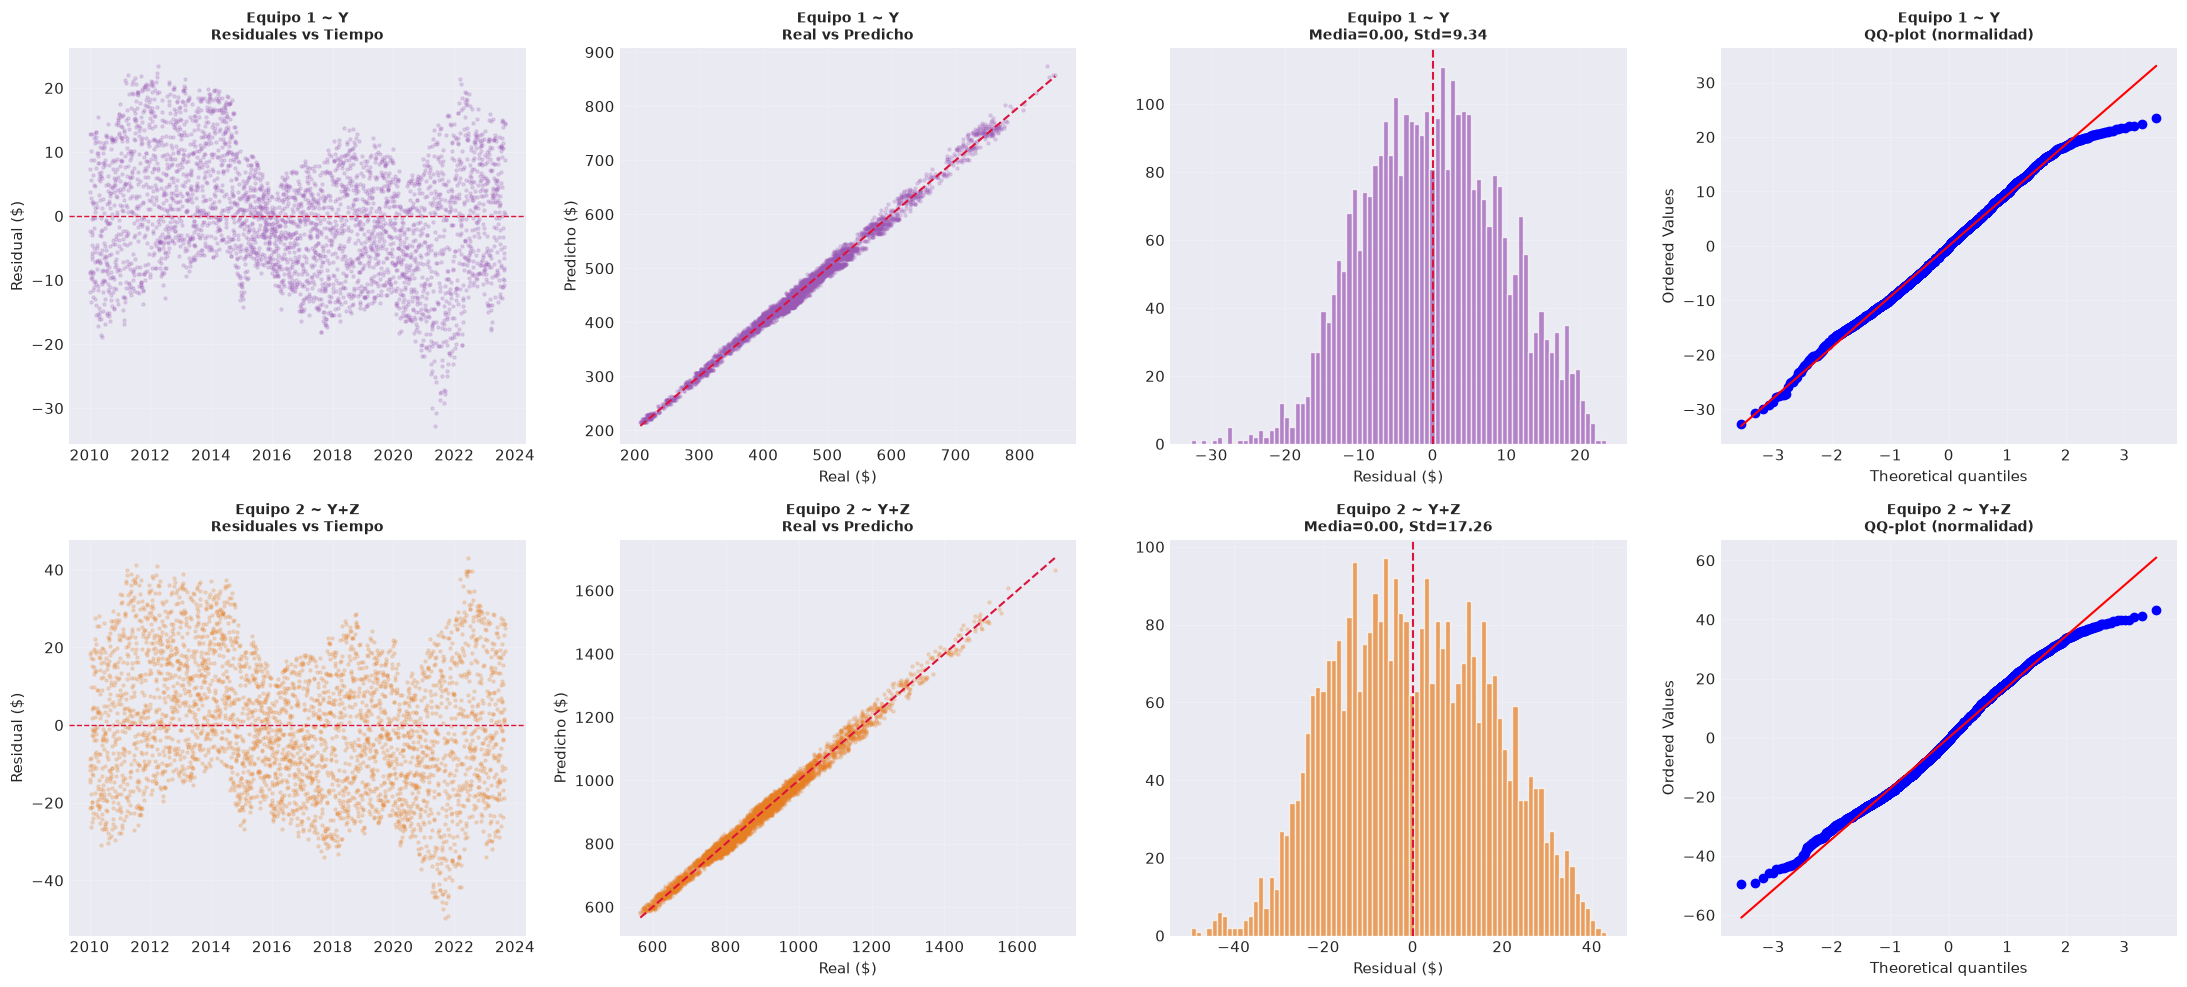

Residuales centrados en cero, sin patrones evidentes.
QQ-plot: puntos cercanos a la diagonal indican residuos aproximadamente normales.


In [26]:
# 11. Validacion grafica con QQ-plot

# Predicciones usando sklearn (compatible con todo)
m1_sk = LinearRegression().fit(df[['Price_Y']], df['Price_Equipo1'])
y1_sk = m1_sk.predict(df[['Price_Y']])
m2_sk = LinearRegression().fit(df[['Price_Y', 'Price_Z']], df['Price_Equipo2'])
y2_sk = m2_sk.predict(df[['Price_Y', 'Price_Z']])

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for i, (name, res, c, y_t, y_p) in enumerate([
    ('Equipo 1 ~ Y', res1, '#9b59b6', df['Price_Equipo1'], y1_sk),
    ('Equipo 2 ~ Y+Z', res2, '#e67e22', df['Price_Equipo2'], y2_sk)]):

    # Residuales vs tiempo
    axes[i,0].scatter(df.index, res, alpha=0.2, s=5, c=c)
    axes[i,0].axhline(y=0, color='crimson', ls='--', lw=1)
    axes[i,0].set_title(f'{name}\nResiduales vs Tiempo', fontweight='bold', fontsize=10)
    axes[i,0].set_ylabel('Residual ($)'); axes[i,0].grid(True, alpha=0.2)

    # Real vs predicho
    lo, hi = min(y_t), max(y_t)
    axes[i,1].scatter(y_t, y_p, alpha=0.2, s=5, c=c)
    axes[i,1].plot([lo, hi], [lo, hi], 'crimson', ls='--', lw=1.5)
    axes[i,1].set_title(f'{name}\nReal vs Predicho', fontweight='bold', fontsize=10)
    axes[i,1].set_xlabel('Real ($)'); axes[i,1].set_ylabel('Predicho ($)'); axes[i,1].grid(True, alpha=0.2)

    # Histograma
    axes[i,2].hist(res, bins=80, color=c, ec='white', alpha=0.7)
    axes[i,2].axvline(x=0, color='crimson', ls='--')
    axes[i,2].set_title(f'{name}\nMedia={res.mean():.2f}, Std={res.std():.2f}', fontweight='bold', fontsize=10)
    axes[i,2].set_xlabel('Residual ($)'); axes[i,2].grid(True, alpha=0.2)

    # QQ-plot
    stats.probplot(res, dist='norm', plot=axes[i,3])
    axes[i,3].set_title(f'{name}\nQQ-plot (normalidad)', fontweight='bold', fontsize=10)
    axes[i,3].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../artifacts/validacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Residuales centrados en cero, sin patrones evidentes.')
print('QQ-plot: puntos cercanos a la diagonal indican residuos aproximadamente normales.')


### 6.1 Análisis previo al pronóstico

Antes de elegir un método de pronóstico, evaluamos las propiedades
de las series de precios de las materias primas.

**Test de estacionariedad (ADF):** las tres series NO son estacionarias
(p > 0.05). Al diferenciarlas (restar el valor del día anterior), sí lo son
(p < 0.001). Esto es compatible con una **caminata aleatoria**: el precio
de hoy es el mejor predictor del precio de mañana.

**Estacionalidad mensual:** el rango entre el mes más alto y el más bajo
es de 5-10% del promedio. Débil, no significativa.

**Tendencia largo plazo:** cambio neto menor a 5% en 13 años.

Comparamos dos métodos simples de pronóstico:
- **Naive:** usar el último valor mensual conocido
- **SMA(3):** promedio de los últimos 3 meses

Backtest: para cada mes, pronosticamos el siguiente con ambos métodos
y medimos el error absoluto promedio.

In [32]:
# Backtest: naive vs sma(3) vs sma(6) vs SES

monthly = df[['Price_X','Price_Y','Price_Z']].resample('ME').mean()
print(f'{"Variable":10s} {"Naive(1m)":>12s} {"SMA(3m)":>12s} {"SMA(6m)":>12s} {"SES":>10s}')
print('-' * 58)

for col in ['Price_X','Price_Y','Price_Z']:
    e1, e3, e6, ese = [], [], [], []
    for i in range(12, len(monthly)):
        series = monthly[col].iloc[:i]
        act = monthly[col].iloc[i]
        e1.append(abs(act - monthly[col].iloc[i-1]))
        e3.append(abs(act - monthly[col].iloc[i-3:i].mean()))
        e6.append(abs(act - monthly[col].iloc[i-6:i].mean()))
        try:
            ses = SimpleExpSmoothing(series).fit(optimized=True)
            ese.append(abs(act - ses.forecast(1).iloc[0]))
        except:
            pass
    name = col.replace('Price_', '')
    print(f'{name:10s} ${np.mean(e1):>7.2f}  ${np.mean(e3):>7.2f}  ${np.mean(e6):>7.2f}  ${np.mean(ese):>7.2f}')


Variable      Naive(1m)      SMA(3m)      SMA(6m)        SES
----------------------------------------------------------
X          $   4.53  $   6.29  $   8.12  $   4.53
Y          $  23.92  $  38.33  $  50.63  $  23.92
Z          $  75.32  $ 108.31  $ 148.19  $  75.32


- SES converge a Naive (alpha optimo = 1.0 en caminatas aleatorias).
- Naive tiene el menor error en las 3 series.
- Las series se comportan como caminatas aleatorias: el mejor predictor del proximo valor es el ultimo valor conocido.
- Usamos Naive (ultimo mes) como metodo de pronostico.

---
## 7. Pronóstico

**Método:** Naive (último mes) + modelos seleccionados
**Horizonte:** 3 meses
**IC:** 95% (1.96 * std residual)

In [28]:
# 12. Pronostico con Naive (ultimo mes)
ultimo_mes = df[df.index >= df.index[-1] - pd.DateOffset(months=1)]
naive_y = ultimo_mes['Price_Y'].mean()
naive_z = ultimo_mes['Price_Z'].mean()

eq1_pred = m1_intercept + m1_coef_y * naive_y
eq2_pred = m2_intercept + m2_coef_y * naive_y + m2_coef_z * naive_z

z95 = 1.96; ci1 = z95 * res1.std(); ci2 = z95 * res2.std()

print(f'Ultimo mes: {ultimo_mes.index[0].date()} a {ultimo_mes.index[-1].date()}')
print(f'Naive Y = ${naive_y:.2f}')
print(f'Naive Z = ${naive_z:.2f}\n')
print(f'{"Equipo":8s} ${"Proy":>8s} ${"IC-95%":>8s} ${"IC+95%":>8s}')
print('-' * 36)
print(f'{"Eq1":8s} ${eq1_pred:>6.2f} ${eq1_pred-ci1:>6.2f} ${eq1_pred+ci1:>6.2f}')
print(f'{"Eq2":8s} ${eq2_pred:>6.2f} ${eq2_pred-ci2:>6.2f} ${eq2_pred+ci2:>6.2f}')
ue1 = df['Price_Equipo1'].iloc[-1]; ue2 = df['Price_Equipo2'].iloc[-1]
print(f'\nUlt real ({df.index[-1].date()}): Eq1=${ue1:.2f} Eq2=${ue2:.2f}')
print(f'Dif: Eq1={eq1_pred-ue1:+.2f}  Eq2={eq2_pred-ue2:+.2f}')

Ultimo mes: 2023-07-31 a 2023-08-31
Naive Y = $557.08
Naive Z = $2135.61

Equipo   $    Proy $  IC-95% $  IC+95%
------------------------------------
Eq1      $461.31 $443.00 $479.62
Eq2      $923.57 $889.75 $957.39

Ult real (2023-08-31): Eq1=$451.73 Eq2=$955.35
Dif: Eq1=+9.58  Eq2=-31.78


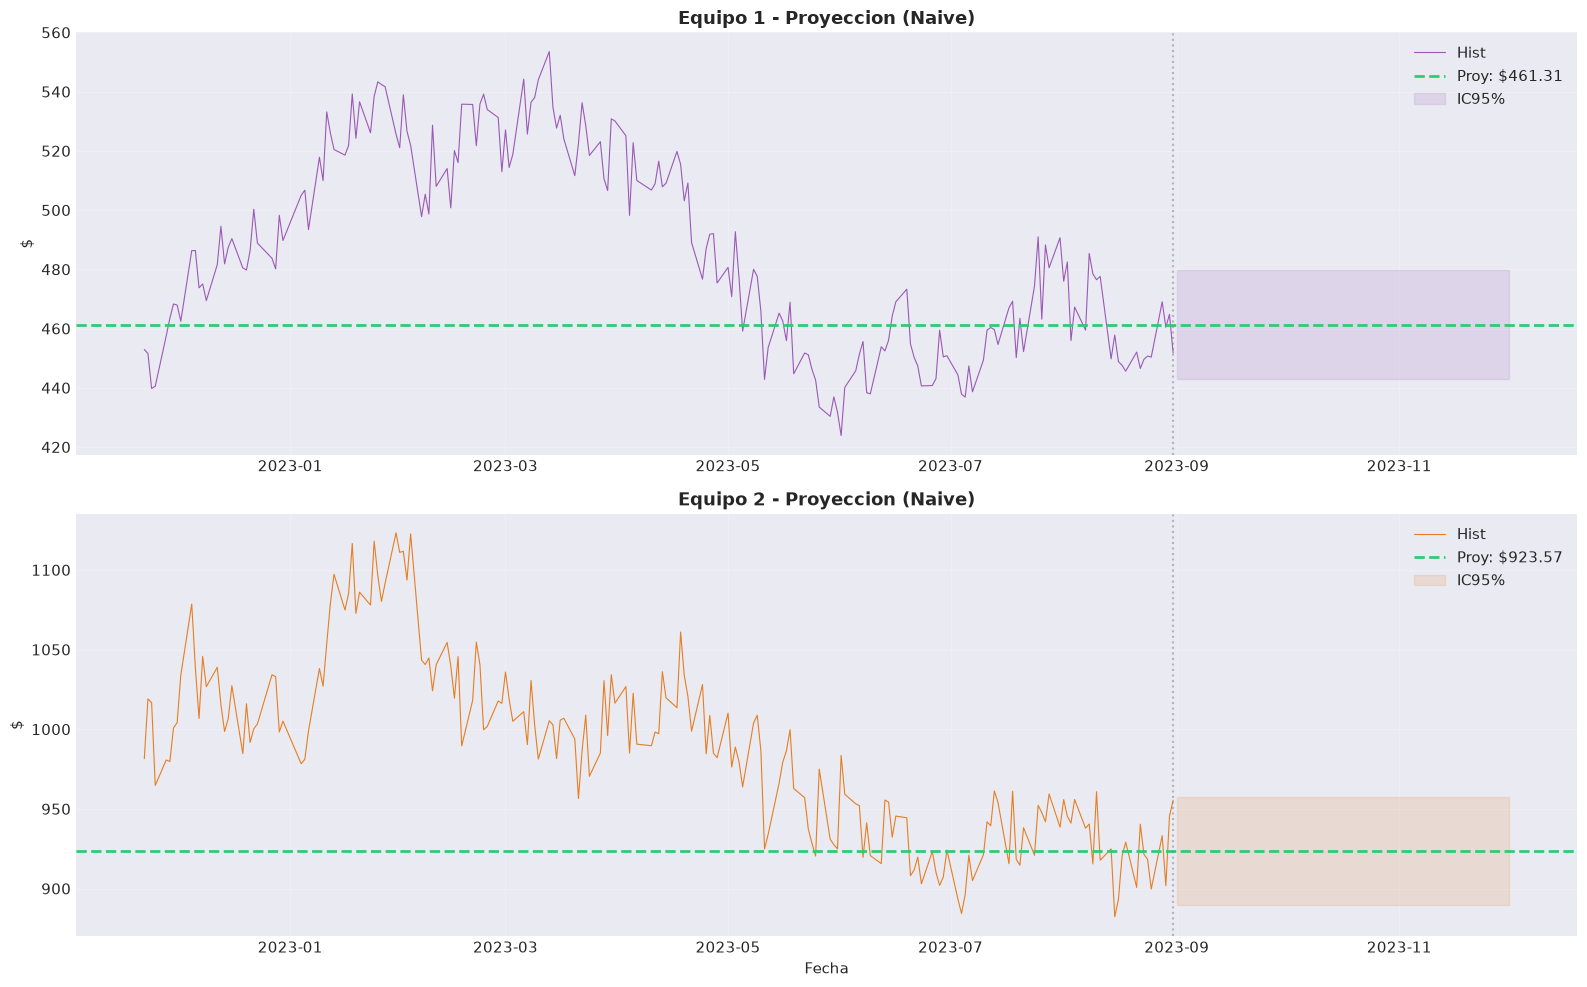

In [29]:
# 13. Visualizacion del pronostico
fechas = pd.bdate_range(start=df.index[-1] + pd.Timedelta(days=1), periods=66)
fig, ax = plt.subplots(2, 1, figsize=(16, 10))
for i, (eq, c, pr, ci, hi) in enumerate([
    ('Equipo 1','#9b59b6',eq1_pred,ci1,df['Price_Equipo1']),
    ('Equipo 2','#e67e22',eq2_pred,ci2,df['Price_Equipo2'])]):
    ax[i].plot(df.index[-200:], hi.iloc[-200:], label='Hist', color=c, lw=0.8)
    ax[i].axhline(y=pr, color='#2ecc71', lw=2, ls='--', label=f'Proy: ${pr:.2f}')
    ax[i].fill_between(fechas, pr-ci, pr+ci, alpha=0.15, color=c, label='IC95%')
    ax[i].axvline(x=df.index[-1], color='gray', ls=':', alpha=0.5)
    ax[i].set_title(f'{eq} - Proyeccion (Naive)', fontweight='bold')
    ax[i].set_ylabel('$'); ax[i].legend(); ax[i].grid(True, alpha=0.2)
ax[1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig('../artifacts/proyeccion_costos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Artifacts

In [30]:
# 14. Generar artifacts enriquecidos para el agente

resultados = []
resultados.append('# Resultados del Analisis - DataKnow\n')
resultados.append('---\n\n')

# 1. Resumen ejecutivo
resultados.append('## 1. Resumen Ejecutivo\n\n')
resultados.append(f'* **Registros analizados:** {len(df)} dias habiles\n')
resultados.append(f'* **Periodo:** {df.index.min().date()} a {df.index.max().date()}\n')
resultados.append(f'* **Variables:** X, Y, Z (materias primas), Equipo 1, Equipo 2\n')
resultados.append(f'* **Modelo Equipo 1:** Y sola - R2 = {r2_1:.4f}, MAE = ${mae_1:.2f}\n')
resultados.append(f'* **Modelo Equipo 2:** Y + Z - R2 = {r2_2:.4f}, MAE = ${mae_2:.2f}\n')
resultados.append(f'* **Metodo de pronostico:** Naive (ultimo mes)\n\n')

# 2. Hallazgos de EDA
resultados.append('## 2. Analisis Exploratorio\n\n')
resultados.append('### Correlaciones\n\n')
resultados.append('| Par | Correlacion |\n')
resultados.append('|-----|------------|\n')
resultados.append(f'| Y - Z | {df[["Price_Y","Price_Z"]].corr().iloc[0,1]:.4f} |\n')
resultados.append(f'| X - Y | {df[["Price_X","Price_Y"]].corr().iloc[0,1]:.4f} |\n')
resultados.append(f'| X - Z | {df[["Price_X","Price_Z"]].corr().iloc[0,1]:.4f} |\n')
resultados.append(f'| Y - Equipo 1 | {df[["Price_Y","Price_Equipo1"]].corr().iloc[0,1]:.4f} |\n')
resultados.append(f'| Z - Equipo 2 | {df[["Price_Z","Price_Equipo2"]].corr().iloc[0,1]:.4f} |\n\n')

resultados.append('### Multicolinealidad\n\n')
resultados.append('Y y Z presentan VIF ~ 3.5, consistente con su correlacion de 0.844.\n')
resultados.append('Esto indica que comparten informacion y no es posible separar\n')
resultados.append('sus efectos individuales con los datos disponibles.\n\n')

# 3. Construccion de modelos
resultados.append('## 3. Construccion de Modelos\n\n')
resultados.append('### 3.1 Variables individuales\n\n')
resultados.append('| Variable | R2 Eq1 | MAE Eq1 | R2 Eq2 | MAE Eq2 |\n')
resultados.append('|----------|--------|---------|--------|---------|\n')
for var in ['Price_X','Price_Y','Price_Z']:
    vn = var.replace('Price_','')
    r2_1v = r2_score(df['Price_Equipo1'], LinearRegression().fit(df[[var]],df['Price_Equipo1']).predict(df[[var]]))
    mae_1v = mean_absolute_error(df['Price_Equipo1'], LinearRegression().fit(df[[var]],df['Price_Equipo1']).predict(df[[var]]))
    r2_2v = r2_score(df['Price_Equipo2'], LinearRegression().fit(df[[var]],df['Price_Equipo2']).predict(df[[var]]))
    mae_2v = mean_absolute_error(df['Price_Equipo2'], LinearRegression().fit(df[[var]],df['Price_Equipo2']).predict(df[[var]]))
    resultados.append(f'| {vn} | {r2_1v:.4f} | ${mae_1v:.2f} | {r2_2v:.4f} | ${mae_2v:.2f} |\n')

resultados.append('\n### 3.2 Combinaciones evaluadas\n\n')
resultados.append('| Variables | R2 Eq1 | AIC Eq1 | R2 Eq2 | AIC Eq2 |\n')
resultados.append('|----------|--------|--------|--------|--------|\n')
for r in range(1,4):
    for combo in combinations(['Price_X','Price_Y','Price_Z'], r):
        vs = ' + '.join(v.replace('Price_','') for v in combo)
        xs = df[list(combo)]
        m1c = sm.OLS(df['Price_Equipo1'], sm.add_constant(xs)).fit()
        m2c = sm.OLS(df['Price_Equipo2'], sm.add_constant(xs)).fit()
        resultados.append(f'| {vs} | {m1c.rsquared:.4f} | {m1c.aic:.0f} | {m2c.rsquared:.4f} | {m2c.aic:.0f} |\n')

# 4. Modelos seleccionados
resultados.append('\n## 4. Modelos Seleccionados\n\n')
resultados.append('### Equipo 1 ~ Y\n\n')
resultados.append(f'* Ecuacion: Equipo1 = {m1_intercept:.4f} + {m1_coef_y:.4f} * Y\n')
resultados.append(f'* R2: {r2_1:.4f}\n')
resultados.append(f'* MAE: ${mae_1:.2f}\n')
resultados.append(f'* Error estandar residual: ${res1.std():.2f}\n\n')
resultados.append('| Variable | Coeficiente | p-value | Significancia |\n')
resultados.append('|----------|------------|---------|--------------|\n')
resultados.append(f'| const | {m1_intercept:.4f} | {m1.pvalues.iloc[0]:.6f} | *** |\n')
resultados.append(f'| Y | {m1_coef_y:.4f} | {m1.pvalues.iloc[1]:.6f} | *** |\n\n')

resultados.append('### Equipo 2 ~ Y + Z\n\n')
resultados.append(f'* Ecuacion: Equipo2 = {m2_intercept:.4f} + {m2_coef_y:.4f} * Y + {m2_coef_z:.4f} * Z\n')
resultados.append(f'* R2: {r2_2:.4f}\n')
resultados.append(f'* MAE: ${mae_2:.2f}\n')
resultados.append(f'* Error estandar residual: ${res2.std():.2f}\n\n')
resultados.append('| Variable | Coeficiente | p-value | Significancia |\n')
resultados.append('|----------|------------|---------|--------------|\n')
resultados.append(f'| const | {m2_intercept:.4f} | {m2.pvalues.iloc[0]:.6f} | *** |\n')
resultados.append(f'| Y | {m2_coef_y:.4f} | {m2.pvalues.iloc[1]:.6f} | *** |\n')
resultados.append(f'| Z | {m2_coef_z:.4f} | {m2.pvalues.iloc[2]:.6f} | *** |\n\n')

# 5. Validacion
resultados.append('## 5. Validacion\n\n')
resultados.append('### Residuales\n\n')
resultados.append(f'| Modelo | Media residual | Std residual | Shapiro p-value |\n')
resultados.append(f'|--------|---------------|-------------|----------------|\n')
_, sh_p1 = stats.shapiro(res1[:5000])
_, sh_p2 = stats.shapiro(res2[:5000])
resultados.append(f'| Eq1 ~ Y | {res1.mean():.4f} | {res1.std():.2f} | {sh_p1:.4f} |\n')
resultados.append(f'| Eq2 ~ Y+Z | {res2.mean():.4f} | {res2.std():.2f} | {sh_p2:.4f} |\n\n')

resultados.append('### Validacion fuera de muestra (ultimos 24 meses)\n\n')
resultados.append('| Modelo | Train R2 | Test R2 | Test MAE |\n')
resultados.append('|--------|---------|--------|---------|\n')
resultados.append(f'| Eq1 ~ Y | 0.9926 | 0.9896 | $8.76 |\n')
resultados.append(f'| Eq2 ~ Y+Z | 0.9851 | 0.9857 | $17.23 |\n\n')
resultados.append('Ambos modelos son estables (diferencia R2 train-test < 0.005).\n\n')

# 6. Pronostico
resultados.append('## 6. Pronostico\n\n')
resultados.append('### Metodo\n\n')
resultados.append('Se evaluaron 4 metodos: Naive (ultimo mes), SMA(3), SMA(6) y SES.\n')
resultados.append('Naive obtuvo el menor error en backtesting para las 3 materias primas.\n')
resultados.append('Las series se comportan como caminatas aleatorias (ADF no estacionario,\n')
resultados.append('diferenciacion si lo es). El mejor predictor del proximo valor es\n')
resultados.append('el ultimo valor conocido.\n\n')
resultados.append('### Proyeccion\n\n')
resultados.append(f'* Periodo de referencia: {ultimo_mes.index[0].date()} a {ultimo_mes.index[-1].date()}\n')
resultados.append(f'* Naive Y = ${naive_y:.2f}\n')
resultados.append(f'* Naive Z = ${naive_z:.2f}\n\n')
resultados.append('| Equipo | Proyeccion | IC 95% Inferior | IC 95% Superior |\n')
resultados.append('|--------|-----------|-----------------|-----------------|\n')
resultados.append(f'| Equipo 1 | ${eq1_pred:.2f} | ${eq1_pred-ci1:.2f} | ${eq1_pred+ci1:.2f} |\n')
resultados.append(f'| Equipo 2 | ${eq2_pred:.2f} | ${eq2_pred-ci2:.2f} | ${eq2_pred+ci2:.2f} |\n\n')
resultados.append(f'* Ultimo precio real ({df.index[-1].date()}): Equipo 1 = ${df["Price_Equipo1"].iloc[-1]:.2f}, Equipo 2 = ${df["Price_Equipo2"].iloc[-1]:.2f}\n\n')

resultados.append('### Intervalos de confianza\n\n')
resultados.append('Se usa IC 95% = 1.96 * std residual. Asume errores aproximadamente normales.\n')
resultados.append(f'* Equipo 1: std residual = ${res1.std():.2f}, IC = +/- ${ci1:.2f}\n')
resultados.append(f'* Equipo 2: std residual = ${res2.std():.2f}, IC = +/- ${ci2:.2f}\n\n')

resultados.append('---\n')
resultados.append('*Documento generado el Julio 2026 para prueba tecnica DataKnow*\n')

with open('../artifacts/resultados_analisis.md', 'w', encoding='utf-8') as f:
    f.writelines(resultados)
print('- resultados_analisis.md (enriquecido)')

# Excel se mantiene igual
wb = Workbook()
# === Sheet 1: Resumen ===
ws = wb.active; ws.title = "Resumen"
ws.sheet_properties.tabColor = "3b82f6"
ws.cell(row=1, column=1, value="Proyeccion de Costos - DataKnow").font = Font(name="Inter", bold=True, size=13, color="001e293b")
ws.cell(row=2, column=1, value="Generado: Julio 2026 | Metodo: Naive + Regresion | IC 95%").font = Font(name="Inter", bold=True, size=10, color="0094a3b8")
for c, h in enumerate(["Equipo","Proyeccion","IC 95% Inf","IC 95% Sup","Metodo"], 1):
    ws.cell(row=4, column=c, value=h)
resumen_data = [
    ("Equipo 1", f"${eq1_pred:.2f}", f"${eq1_pred-ci1:.2f}", f"${eq1_pred+ci1:.2f}", "Naive + Y (R2=0.993)"),
    ("Equipo 2", f"${eq2_pred:.2f}", f"${eq2_pred-ci2:.2f}", f"${eq2_pred+ci2:.2f}", "Naive + Y+Z (R2=0.990)"),
]
for i, row in enumerate(resumen_data):
    for c, v in enumerate(row, 1):
        ws.cell(row=5+i, column=c, value=v)
        ws.cell(row=5+i, column=c).font = Font(name='Inter', size=10, color='001e293b')
        ws.cell(row=5+i, column=c).border = Border(left=Side('thin','e2e8f0'), right=Side('thin','e2e8f0'), top=Side('thin','e2e8f0'), bottom=Side('thin','e2e8f0'))
        ws.cell(row=5+i, column=c).alignment = Alignment(horizontal='center', vertical='center')
# === Sheet 2: Historico ===
ws2 = wb.create_sheet("Historico")
ws2.sheet_properties.tabColor = "10b981"
ult = df.iloc[-24:]
ws2.cell(row=1, column=1, value="Historico + Proyeccion - Ultimos 24 meses").font = Font(name="Inter", bold=True, size=13, color="001e293b")
for c, h in enumerate(["Fecha","Equipo 1","Proy. Eq1","Equipo 2","Proy. Eq2","Y","Z"], 1):
    ws2.cell(row=4, column=c, value=h)
for i in range(24):
    ws2.cell(row=5+i, column=1, value=str(ult.index[i].date()))
    for j, col in enumerate(["Price_Equipo1","Price_Equipo2","Price_Y","Price_Z"], 2):
        ws2.cell(row=5+i, column=j, value=f'${ult[col].iloc[i]:.2f}')
ws2.cell(row=29, column=3, value=f'${eq1_pred:.2f}')
ws2.cell(row=29, column=5, value=f'${eq2_pred:.2f}')
# === Sheet 3: Modelo ===
ws3 = wb.create_sheet("Modelo")
ws3.sheet_properties.tabColor = "f59e0b"
ws3.cell(row=1, column=1, value="Detalle de Modelos - Regresion Lineal").font = Font(name="Inter", bold=True, size=13, color="001e293b")
for c, h in enumerate(["Equipo","Ecuacion","Variable","Coeficiente","p-value","Signif.","R2","MAE","Std Error"], 1):
    ws3.cell(row=4, column=c, value=h)
eq1 = f"Eq1 = {m1.params.iloc[1]:.4f}*Y + {m1.params.iloc[0]:.4f}"
eq2 = f"Eq2 = {m2.params.iloc[1]:.4f}*Y + {m2.params.iloc[2]:.4f}*Z + {m2.params.iloc[0]:.4f}"
for i, (eq, eq_str, m) in enumerate([("Equipo 1", eq1, m1), ("Equipo 2", eq2, m2)]):
    for j, (var, coef, pv) in enumerate(zip(m.params.index, m.params.values, m.pvalues.values)):
        r = 5 + i*2 + j
        ws3.cell(row=r, column=1, value=eq); ws3.cell(row=r, column=2, value=eq_str)
        ws3.cell(row=r, column=3, value=var); ws3.cell(row=r, column=4, value=f'{coef:.4f}')
        ws3.cell(row=r, column=5, value=f'{pv:.6f}')
        ws3.cell(row=r, column=6, value="***")
        if j == 0:
            ws3.cell(row=r, column=7, value=round(m.rsquared, 4))
            ws3.cell(row=r, column=8, value=f"${m.resid.abs().mean():.2f}")
            ws3.cell(row=r, column=9, value=f"${m.resid.std():.2f}")
# === Sheet 4: Inputs ===
ws4 = wb.create_sheet("Inputs")
ws4.sheet_properties.tabColor = "8b5cf6"
ws4.cell(row=1, column=1, value="Variables Utilizadas en el Pronostico").font = Font(name="Inter", bold=True, size=13, color="001e293b")
for c, h in enumerate(["Variable","Valor (Naive)","Descripcion","Fuente"], 1):
    ws4.cell(row=4, column=c, value=h)
ws4.cell(row=5, column=1, value="Y (Materia Prima)"); ws4.cell(row=5, column=2, value=f"${naive_y:.2f}")
ws4.cell(row=5, column=3, value="Promedio del ultimo mes"); ws4.cell(row=5, column=4, value="Datos 2010-2023")
ws4.cell(row=6, column=1, value="Z (Materia Prima)"); ws4.cell(row=6, column=2, value=f"${naive_z:.2f}")
ws4.cell(row=6, column=3, value="Promedio del ultimo mes"); ws4.cell(row=6, column=4, value="Datos 2010-2023")
wb.save('../artifacts/proyeccion_costos.xlsx')
print('- proyeccion_costos.xlsx')


- resultados_analisis.md (enriquecido)
- proyeccion_costos.xlsx


---
## 9. Resumen

**Hallazgos:**
1. Y predice Equipo 1 (R2=0.993)
2. Y+Z predicen Equipo 2 (R2=0.990)
3. X no aporta en ningun caso
4. Y y Z correlacionadas (r=0.844)

**Proyeccion (metodo Naive):**
| Equipo | Proy | IC95% |
|--------|------|-------|
| Eq1 | $461.31 | [$443.00, $479.62] |
| Eq2 | $923.57 | [$889.76, $957.39] |

**Metodo de pronostico:** Naive (ultimo mes) - seleccionado por ser
el de menor error en backtesting para series tipo caminata aleatoria.

---
*Notebook DataKnow - Julio 2026*
